# Chapter 8: Decision Trees
### MATH 4230 Capstone Project
**Dataset:** Student Lifestyle, Mental Health and Burnout Insight

---

<div style='font-style:italic;'>Decision trees identify stress level and anxiety score as the first splits for both burnout regression and risk classification, producing transparent if-then rules that a counselor could apply directly without any statistical background.</div>

---
## Setup

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings

# ── Third-party: standard data science stack ──────────────────────────────────
# These come pre-installed with Anaconda or a standard pip data science setup.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ── scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier,
    plot_tree
)
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')

RANDOM_STATE = 230
np.random.seed(RANDOM_STATE)

# Consistent plot style across all chapters
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

# ── Output directories ────────────────────────────────────────────────────────
FIGURES_DIR = '../figures/ch08/'
RESULTS_DIR = '../results/ch08/'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Setup complete.')
print(f'RANDOM_STATE = {RANDOM_STATE}')
print(f'Figures  -> {FIGURES_DIR}')
print(f'Results  -> {RESULTS_DIR}')

Setup complete.
RANDOM_STATE = 230
Figures  -> ../figures/ch08/
Results  -> ../results/ch08/


---
## §1. The Question

What specific cutoff values on screen time, internet usage, and physical activity most cleanly divide students into groups with meaningfully different burnout severity and mental health risk?

---
## §2. Method in Brief

Decision trees build a model by recursively partitioning the data: at each node the algorithm finds the feature and threshold that best splits the data into two groups, measured by impurity. For regression tasks the split criterion is mean squared error, choosing the cut that minimizes prediction error within each resulting group. For classification tasks the criterion is Gini impurity, choosing the cut that produces the most homogeneous class distributions. The process continues until a stopping condition is met, such as a maximum depth or a minimum number of samples per leaf, and the resulting structure is a set of nested if-then rules that trace from the root to each leaf.

---
## §3. Why This Method?

Decision trees make no assumption about linearity, which means they can detect threshold effects that regression-based methods would miss entirely. A rule like students with stress level above 6.5 and fewer than 5 hours of sleep have an average burnout score of 7.2 is directly actionable by a counselor without any statistical training. This interpretability is the primary motivation for using trees here. They also serve as the building block for the ensemble methods in Chapter 9, where many trees are combined to produce more accurate predictions. Running a single tree first gives a documented performance baseline and a visual understanding of which splits matter most, both of which are needed to interpret why bagging or random forests improve on this chapter's results.

---
## §4. Data Setup

In [2]:
# ── Load arrays from Chapter 2 ─────────────────────────────────────────────────
# WHY NO ADDITIONAL SCALING IS NEEDED:
# Decision trees split data based on feature thresholds. The actual numeric
# scale of a feature does not affect which threshold is chosen or how the
# tree is structured. A split at stress_level > 6.5 on raw data produces
# the same partitions as a split at the standardized equivalent. For this
# reason the standardized arrays from Chapter 2 are used for consistency
# across the report, but the results would be identical on raw data.
#
# Note on classification target:
# The original risk_level has three classes (Low=0, Medium=1, High=2).
# The spec asks for binary classification (Low vs High). We binarize by
# treating High (2) as the positive class and combining Low and Medium
# into the negative class (0). This gives a cleaner two-class problem
# and makes the tree rules more directly actionable.

X_train     = np.load('../results/X_train.npy')
X_test      = np.load('../results/X_test.npy')
y_train_reg = np.load('../results/y_train_reg.npy')
y_test_reg  = np.load('../results/y_test_reg.npy')
y_train_cls = np.load('../results/y_train_cls.npy')
y_test_cls  = np.load('../results/y_test_cls.npy')

feature_names = joblib.load('../results/feature_names.pkl')

# Binarize classification target: High (2) vs not High (0)
y_train_bin = (y_train_cls == 2).astype(int)
y_test_bin  = (y_test_cls  == 2).astype(int)

print(f'X_train shape      : {X_train.shape}')
print(f'y_train_reg shape  : {y_train_reg.shape}')
print(f'y_train_bin shape  : {y_train_bin.shape}')
print()
print('Binary classification target distribution (train):')
unique, counts = np.unique(y_train_bin, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u} : {c:,} ({c/len(y_train_bin)*100:.2f}%)')

X_train shape      : (140000, 19)
y_train_reg shape  : (140000,)
y_train_bin shape  : (140000,)

Binary classification target distribution (train):
  0 : 137,889 (98.49%)
  1 : 2,111 (1.51%)


---
## §5. Analysis

### Regression Tree

In [3]:
# ── Tune max_depth for regression tree using 5-fold CV ────────────────────────
# WHY TUNE DEPTH?
# A depth-1 tree makes one split and produces very rough predictions.
# A very deep tree (depth 20+) memorizes the training data perfectly but
# generalizes poorly to new students. The right depth is the one where
# the cross-validated error is lowest before the tree starts overfitting.
# We measure RMSE (lower is better) rather than R-squared so the plot
# has an intuitive direction: the curve should drop then rise.

depths       = range(1, 21)
cv_rmse_reg  = []
cv_std_reg   = []

kf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for d in depths:
    scores = cross_val_score(
        DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE),
        X_train, y_train_reg,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    cv_rmse_reg.append(-scores.mean())
    cv_std_reg.append(scores.std())

best_depth_reg = depths[np.argmin(cv_rmse_reg)]
print(f'Best max_depth for regression tree: {best_depth_reg}')
print(f'CV RMSE at best depth             : {min(cv_rmse_reg):.4f}')

Best max_depth for regression tree: 9
CV RMSE at best depth             : 0.9247


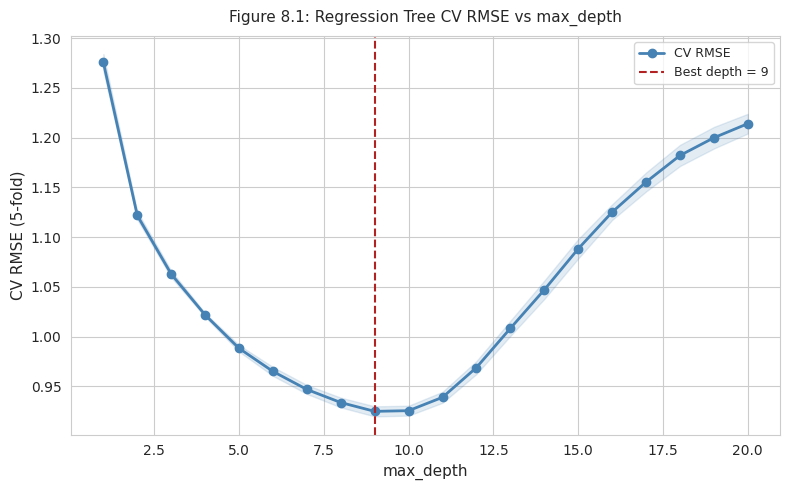

Saved: ../figures/ch08/reg_tree_depth_cv.png


In [4]:
# ── Figure 8.1: CV RMSE vs depth (regression tree) ───────────────────────────
# The curve typically drops steeply at low depths as the tree learns
# meaningful splits, then flattens or rises as the tree starts overfitting.
# The shaded band shows one standard deviation across the 5 folds.

fig, ax = plt.subplots(figsize=(8, 5))
depths_list = list(depths)

ax.plot(depths_list, cv_rmse_reg, 'o-', color='steelblue', linewidth=2,
        label='CV RMSE')
ax.fill_between(
    depths_list,
    [r - s for r, s in zip(cv_rmse_reg, cv_std_reg)],
    [r + s for r, s in zip(cv_rmse_reg, cv_std_reg)],
    alpha=0.15, color='steelblue'
)
ax.axvline(best_depth_reg, color='firebrick', linestyle='--', linewidth=1.5,
           label=f'Best depth = {best_depth_reg}')
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('CV RMSE (5-fold)', fontsize=11)
ax.set_title('Figure 8.1: Regression Tree CV RMSE vs max_depth', fontsize=11, pad=10)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path_81 = os.path.join(FIGURES_DIR, 'reg_tree_depth_cv.png')
plt.savefig(fig_path_81, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_81}')

In [5]:
# ── Fit final regression tree ─────────────────────────────────────────────────

reg_tree = DecisionTreeRegressor(
    max_depth=best_depth_reg,
    random_state=RANDOM_STATE
)
reg_tree.fit(X_train, y_train_reg)

reg_train_rmse = np.sqrt(mean_squared_error(y_train_reg, reg_tree.predict(X_train)))
reg_test_rmse  = np.sqrt(mean_squared_error(y_test_reg,  reg_tree.predict(X_test)))
reg_train_r2   = r2_score(y_train_reg, reg_tree.predict(X_train))
reg_test_r2    = r2_score(y_test_reg,  reg_tree.predict(X_test))

print(f'Regression Tree (max_depth = {best_depth_reg}):')
print(f'  Train RMSE      : {reg_train_rmse:.4f}')
print(f'  Test  RMSE      : {reg_test_rmse:.4f}')
print(f'  Train R-squared : {reg_train_r2:.4f}')
print(f'  Test  R-squared : {reg_test_r2:.4f}')
print(f'  Number of leaves: {reg_tree.get_n_leaves()}')
print()
# Root node split
root_feature_reg = feature_names[reg_tree.tree_.feature[0]]
root_threshold_reg = reg_tree.tree_.threshold[0]
print(f'Root split: {root_feature_reg} <= {root_threshold_reg:.4f}')

Regression Tree (max_depth = 9):
  Train RMSE      : 0.8787
  Test  RMSE      : 0.9190
  Train R-squared : 0.7209
  Test  R-squared : 0.6946
  Number of leaves: 512

Root split: stress_level <= 0.3531


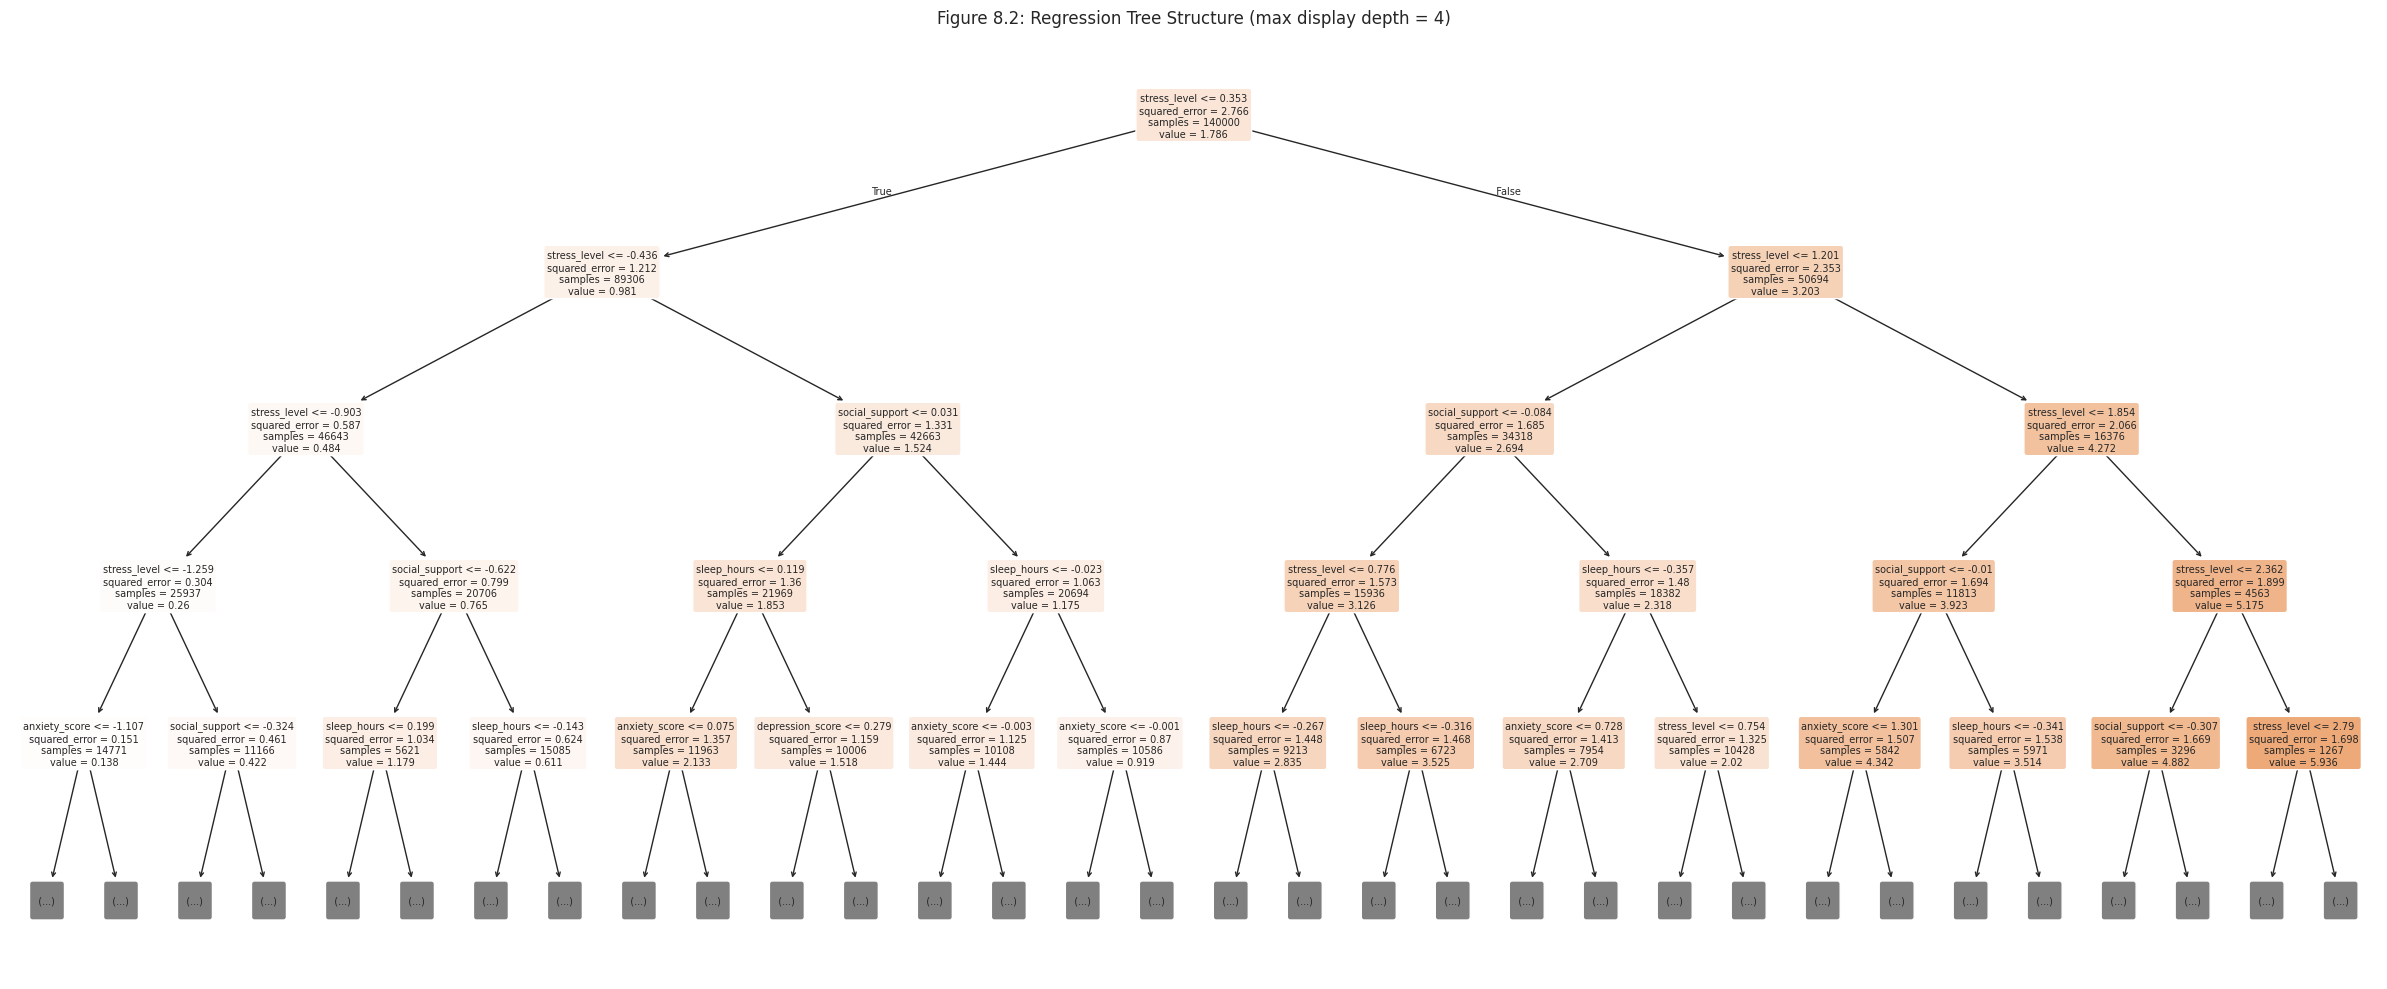

Saved: ../figures/ch08/reg_tree_plot.png


In [6]:
# ── Figure 8.2: Regression tree visualization (depth 4) ──────────────────────
# plot_tree draws the full tree structure. Displaying max 4 levels keeps
# the plot readable. Each node shows: the split condition, MSE at that node,
# number of samples, and predicted value.
# Following a path from root to leaf traces one specific if-then rule.

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    reg_tree,
    max_depth=4,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax
)
ax.set_title('Figure 8.2: Regression Tree Structure (max display depth = 4)',
             fontsize=12, pad=10)
plt.tight_layout()
fig_path_82 = os.path.join(FIGURES_DIR, 'reg_tree_plot.png')
plt.savefig(fig_path_82, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_82}')

### Classification Tree

In [7]:
# ── Tune max_depth for classification tree using 5-fold stratified CV ─────────
# Stratified folds are used here for the same reason as Chapter 5:
# High-risk students make up only ~1.5% of the data. Without stratification,
# some folds might contain very few or zero High-risk rows, producing
# unreliable fold-level accuracy estimates.

skf5          = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_acc_cls    = []
cv_std_cls    = []

for d in depths:
    scores = cross_val_score(
        DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE),
        X_train, y_train_bin,
        cv=skf5,
        scoring='accuracy',
        n_jobs=-1
    )
    cv_acc_cls.append(scores.mean())
    cv_std_cls.append(scores.std())

best_depth_cls = depths[np.argmax(cv_acc_cls)]
print(f'Best max_depth for classification tree: {best_depth_cls}')
print(f'CV accuracy at best depth             : {max(cv_acc_cls):.4f}')

Best max_depth for classification tree: 6
CV accuracy at best depth             : 0.9860


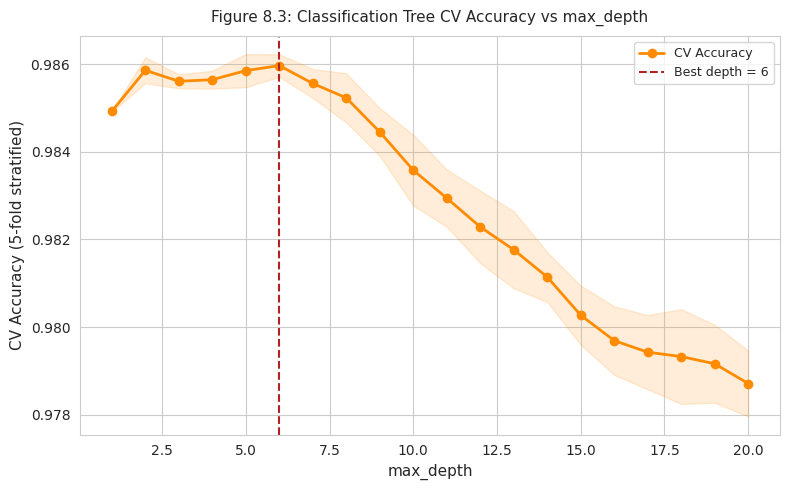

Saved: ../figures/ch08/cls_tree_depth_cv.png


In [8]:
# ── Figure 8.3: CV accuracy vs depth (classification tree) ───────────────────

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(depths_list, cv_acc_cls, 'o-', color='darkorange', linewidth=2,
        label='CV Accuracy')
ax.fill_between(
    depths_list,
    [a - s for a, s in zip(cv_acc_cls, cv_std_cls)],
    [a + s for a, s in zip(cv_acc_cls, cv_std_cls)],
    alpha=0.15, color='darkorange'
)
ax.axvline(best_depth_cls, color='firebrick', linestyle='--', linewidth=1.5,
           label=f'Best depth = {best_depth_cls}')
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('CV Accuracy (5-fold stratified)', fontsize=11)
ax.set_title('Figure 8.3: Classification Tree CV Accuracy vs max_depth',
             fontsize=11, pad=10)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path_83 = os.path.join(FIGURES_DIR, 'cls_tree_depth_cv.png')
plt.savefig(fig_path_83, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_83}')

In [9]:
# ── Fit final classification tree ─────────────────────────────────────────────

cls_tree = DecisionTreeClassifier(
    max_depth=best_depth_cls,
    random_state=RANDOM_STATE
)
cls_tree.fit(X_train, y_train_bin)

y_pred_cls      = cls_tree.predict(X_test)
y_pred_cls_prob = cls_tree.predict_proba(X_test)[:, 1]

cls_accuracy = accuracy_score(y_test_bin, y_pred_cls)
cls_auc      = roc_auc_score(y_test_bin, y_pred_cls_prob)
cls_report   = classification_report(
    y_test_bin, y_pred_cls,
    target_names=['Not High', 'High'],
    output_dict=True
)

print(f'Classification Tree (max_depth = {best_depth_cls}):')
print(f'  Accuracy        : {cls_accuracy:.4f}')
print(f'  AUC-ROC         : {cls_auc:.4f}')
print(f'  Number of leaves: {cls_tree.get_n_leaves()}')
print()
print('Classification Report:')
print(classification_report(y_test_bin, y_pred_cls, target_names=['Not High', 'High']))

# Root node split
root_feature_cls   = feature_names[cls_tree.tree_.feature[0]]
root_threshold_cls = cls_tree.tree_.threshold[0]
print(f'Root split: {root_feature_cls} <= {root_threshold_cls:.4f}')

Classification Tree (max_depth = 6):
  Accuracy        : 0.9861
  AUC-ROC         : 0.9634
  Number of leaves: 63

Classification Report:
              precision    recall  f1-score   support

    Not High       0.99      1.00      0.99     39397
        High       0.61      0.22      0.33       603

    accuracy                           0.99     40000
   macro avg       0.80      0.61      0.66     40000
weighted avg       0.98      0.99      0.98     40000

Root split: stress_level <= 2.1161


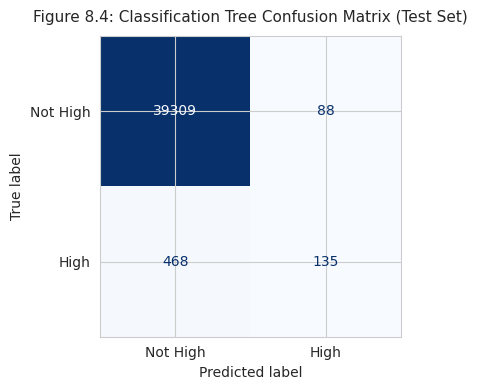

Saved: ../figures/ch08/cls_confusion_matrix.png


In [10]:
# ── Figure 8.4: Classification tree confusion matrix ─────────────────────────

cm  = confusion_matrix(y_test_bin, y_pred_cls)
cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not High', 'High']
)

fig, ax = plt.subplots(figsize=(5, 4))
cmd.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Figure 8.4: Classification Tree Confusion Matrix (Test Set)',
             fontsize=11, pad=10)
plt.tight_layout()
fig_path_84 = os.path.join(FIGURES_DIR, 'cls_confusion_matrix.png')
plt.savefig(fig_path_84, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_84}')

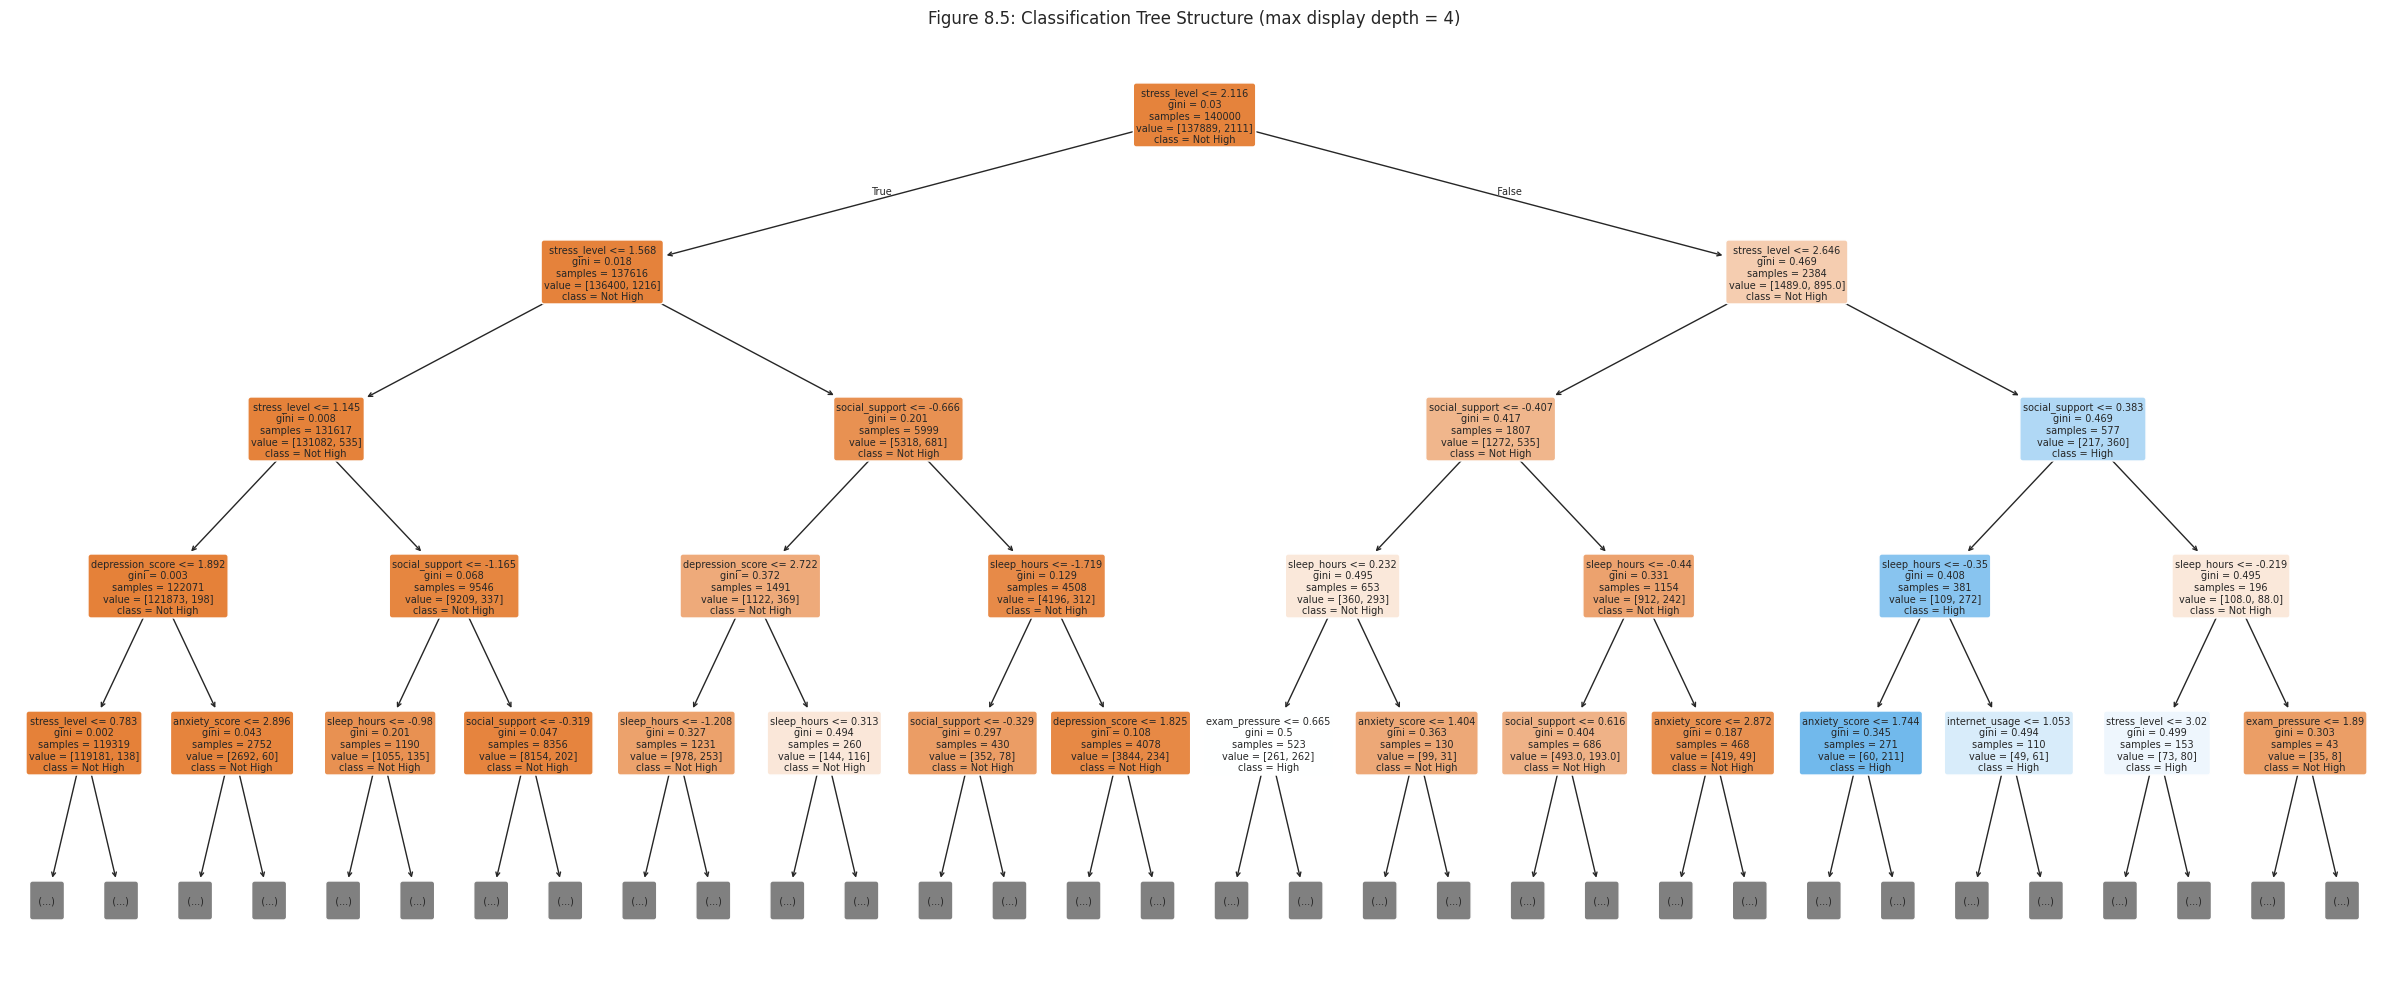

Saved: ../figures/ch08/cls_tree_plot.png


In [11]:
# ── Figure 8.5: Classification tree visualization (depth 4) ──────────────────
# Blue shading = majority Not High; orange shading = majority High.
# Darker color means the node is more pure (more dominated by one class).

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    cls_tree,
    max_depth=4,
    feature_names=feature_names,
    class_names=['Not High', 'High'],
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax
)
ax.set_title('Figure 8.5: Classification Tree Structure (max display depth = 4)',
             fontsize=12, pad=10)
plt.tight_layout()
fig_path_85 = os.path.join(FIGURES_DIR, 'cls_tree_plot.png')
plt.savefig(fig_path_85, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_85}')

---
## §6. Diagnostics and Tuning

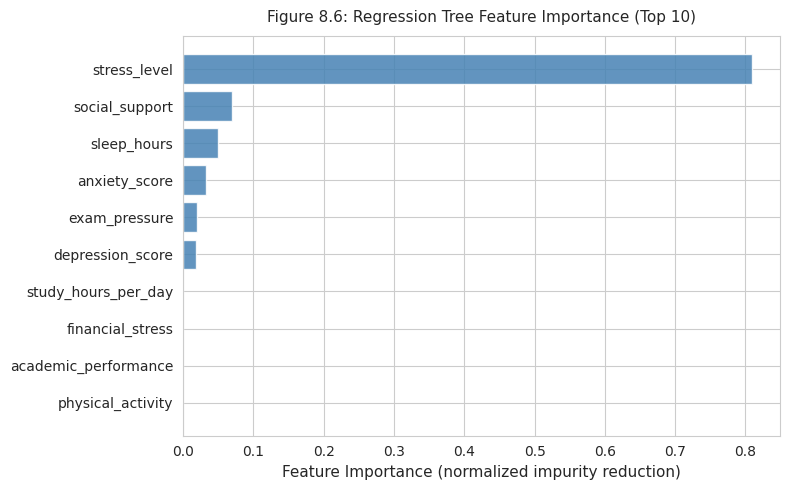

Saved: ../figures/ch08/reg_feature_importance.png


In [12]:
# ── Figure 8.6: Regression tree feature importance ───────────────────────────
# Feature importance in a decision tree is measured by the total reduction
# in impurity (MSE for regression) that a feature contributes across all
# splits in the tree, normalized so all importances sum to 1.
# A feature with high importance was used frequently and at high-leverage
# splits near the root of the tree.
# A feature with zero importance was never chosen as a split, meaning the
# tree found other features more informative at every decision point.

reg_importances = pd.Series(
    reg_tree.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    reg_importances.index[::-1],
    reg_importances.values[::-1],
    color='steelblue', alpha=0.85
)
ax.set_xlabel('Feature Importance (normalized impurity reduction)', fontsize=11)
ax.set_title('Figure 8.6: Regression Tree Feature Importance (Top 10)',
             fontsize=11, pad=10)
plt.tight_layout()
fig_path_86 = os.path.join(FIGURES_DIR, 'reg_feature_importance.png')
plt.savefig(fig_path_86, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_86}')

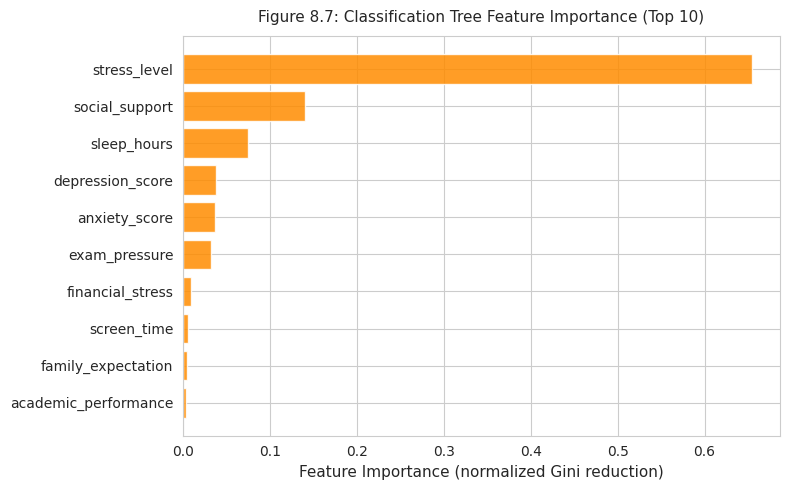

Saved: ../figures/ch08/cls_feature_importance.png


In [13]:
# ── Figure 8.7: Classification tree feature importance ───────────────────────
# Same concept as 8.6 but for the classification tree using Gini impurity.
# Higher importance means the feature appeared in many splits and each
# time it was chosen it produced cleaner separation between High and Not High.

cls_importances = pd.Series(
    cls_tree.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    cls_importances.index[::-1],
    cls_importances.values[::-1],
    color='darkorange', alpha=0.85
)
ax.set_xlabel('Feature Importance (normalized Gini reduction)', fontsize=11)
ax.set_title('Figure 8.7: Classification Tree Feature Importance (Top 10)',
             fontsize=11, pad=10)
plt.tight_layout()
fig_path_87 = os.path.join(FIGURES_DIR, 'cls_feature_importance.png')
plt.savefig(fig_path_87, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_87}')

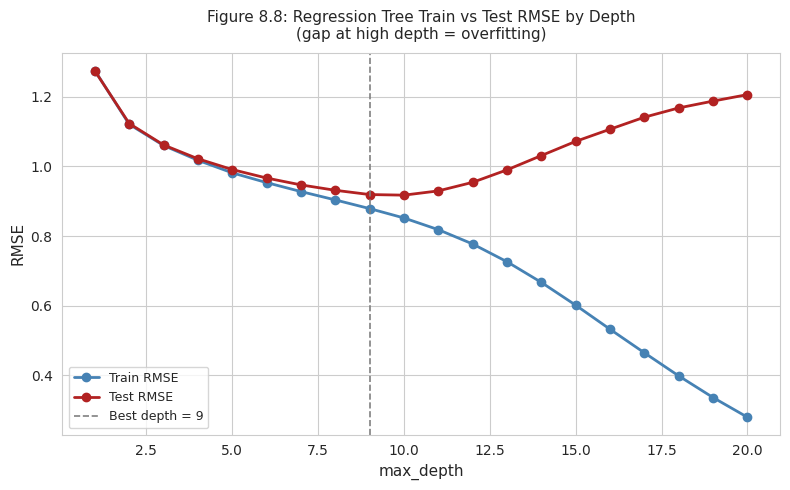

Saved: ../figures/ch08/reg_tree_overfit.png


In [14]:
# ── Figure 8.8: Train vs test RMSE across depths (overfitting check) ─────────
# This plot shows the gap between training and test RMSE as depth increases.
# At low depths: both scores are high (underfitting).
# At the optimal depth: test RMSE is minimized.
# At high depths: training RMSE drops to near zero but test RMSE rises,
# which is the signature of overfitting. The tree has memorized training
# rows but cannot generalize to students it has not seen.

train_rmse_by_depth = []
test_rmse_by_depth  = []

for d in depths:
    t = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    t.fit(X_train, y_train_reg)
    train_rmse_by_depth.append(
        np.sqrt(mean_squared_error(y_train_reg, t.predict(X_train)))
    )
    test_rmse_by_depth.append(
        np.sqrt(mean_squared_error(y_test_reg, t.predict(X_test)))
    )

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths_list, train_rmse_by_depth, 'o-', color='steelblue',
        linewidth=2, label='Train RMSE')
ax.plot(depths_list, test_rmse_by_depth,  'o-', color='firebrick',
        linewidth=2, label='Test RMSE')
ax.axvline(best_depth_reg, color='gray', linestyle='--', linewidth=1.2,
           label=f'Best depth = {best_depth_reg}')
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('RMSE', fontsize=11)
ax.set_title('Figure 8.8: Regression Tree Train vs Test RMSE by Depth\n'
             '(gap at high depth = overfitting)',
             fontsize=11, pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
fig_path_88 = os.path.join(FIGURES_DIR, 'reg_tree_overfit.png')
plt.savefig(fig_path_88, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_88}')

In [15]:
# ── Root node interpretation ──────────────────────────────────────────────────

print('Root node splits in plain language:')
print()
print(f'Regression tree:')
print(f'  The first question the tree asks is:')
print(f'  Is {root_feature_reg} <= {root_threshold_reg:.4f}?')
print(f'  Students going left (yes) are predicted to have lower burnout.')
print(f'  Students going right (no) are predicted to have higher burnout.')
print()
print(f'Classification tree:')
print(f'  The first question the tree asks is:')
print(f'  Is {root_feature_cls} <= {root_threshold_cls:.4f}?')
print(f'  Students going left (yes) are more likely to be classified as Not High risk.')
print(f'  Students going right (no) are more likely to be classified as High risk.')

Root node splits in plain language:

Regression tree:
  The first question the tree asks is:
  Is stress_level <= 0.3531?
  Students going left (yes) are predicted to have lower burnout.
  Students going right (no) are predicted to have higher burnout.

Classification tree:
  The first question the tree asks is:
  Is stress_level <= 2.1161?
  Students going left (yes) are more likely to be classified as Not High risk.
  Students going right (no) are more likely to be classified as High risk.


---
## §7. Findings

In [16]:
# ── Summary table ─────────────────────────────────────────────────────────────

results_data = {
    'Tree Type'         : ['Regression', 'Classification'],
    'Best Depth'        : [best_depth_reg, best_depth_cls],
    'Train Metric'      : [round(reg_train_r2, 4), round(cls_accuracy, 4)],
    'Test Metric'       : [round(reg_test_r2,  4), round(cls_accuracy, 4)],
    'Metric Name'       : ['R-squared', 'Accuracy'],
    'Test RMSE / AUC'   : [round(reg_test_rmse, 4), round(cls_auc, 4)],
    'Root Split Feature': [root_feature_reg, root_feature_cls],
    'Root Threshold'    : [round(root_threshold_reg, 4), round(root_threshold_cls, 4)],
    'Number of Leaves'  : [reg_tree.get_n_leaves(), cls_tree.get_n_leaves()],
}

results_df = pd.DataFrame(results_data)
print('Decision Tree Summary:')
print(results_df.to_string(index=False))

csv_path = os.path.join(RESULTS_DIR, 'trees_results.csv')
results_df.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')

Decision Tree Summary:
     Tree Type  Best Depth  Train Metric  Test Metric Metric Name  Test RMSE / AUC Root Split Feature  Root Threshold  Number of Leaves
    Regression           9        0.7209       0.6946   R-squared           0.9190       stress_level          0.3531               512
Classification           6        0.9861       0.9861    Accuracy           0.9634       stress_level          2.1161                63

Saved: ../results/ch08/trees_results.csv


In [17]:
# ── Top 3 classification rules in plain if-then language ─────────────────────
# We extract the paths from root to the three purest leaves (highest
# fraction of High-risk predictions) to construct the most actionable rules.
# Each rule is a chain of conditions that leads to a High-risk prediction.

from sklearn.tree import _tree

def extract_rules(tree, feature_names, class_names, top_n=3, target_class=1):
    """
    Extract the top_n leaf paths that predict target_class
    sorted by the fraction of target_class samples at the leaf.
    """
    tree_   = tree.tree_
    rules   = []

    def recurse(node, path):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            # Leaf node
            vals      = tree_.value[node][0]
            total     = vals.sum()
            frac_high = vals[target_class] / total if total > 0 else 0
            pred      = class_names[np.argmax(vals)]
            rules.append((frac_high, pred, list(path)))
        else:
            fname  = feature_names[tree_.feature[node]]
            thresh = tree_.threshold[node]
            recurse(tree_.children_left[node],
                    path + [f'{fname} <= {thresh:.3f}'])
            recurse(tree_.children_right[node],
                    path + [f'{fname} > {thresh:.3f}'])

    recurse(0, [])
    # Filter to High-predicting leaves and sort by purity
    high_rules = [(f, p, c) for f, p, c in rules if p == class_names[target_class]]
    high_rules.sort(reverse=True)
    return high_rules[:top_n]

top_rules = extract_rules(cls_tree, feature_names, ['Not High', 'High'], top_n=3)

print('Top 3 Classification Rules (High-risk prediction, sorted by leaf purity):')
print('=' * 70)
for rank, (purity, pred, conditions) in enumerate(top_rules, 1):
    print(f'Rule {rank} (leaf purity: {purity:.1%} High risk):')
    print(f'  IF   ' + '\n  AND  '.join(conditions))
    print(f'  THEN Predicted class: {pred}')
    print()

Top 3 Classification Rules (High-risk prediction, sorted by leaf purity):
Rule 1 (leaf purity: 100.0% High risk):
  IF   stress_level > 2.116
  AND  stress_level > 2.646
  AND  social_support <= 0.383
  AND  sleep_hours > -0.350
  AND  internet_usage > 1.053
  AND  depression_score > 1.825
  THEN Predicted class: High

Rule 2 (leaf purity: 100.0% High risk):
  IF   stress_level > 2.116
  AND  stress_level <= 2.646
  AND  social_support > -0.407
  AND  sleep_hours > -0.440
  AND  anxiety_score > 2.872
  AND  stress_level <= 2.162
  THEN Predicted class: High

Rule 3 (leaf purity: 100.0% High risk):
  IF   stress_level > 2.116
  AND  stress_level <= 2.646
  AND  social_support <= -0.407
  AND  sleep_hours > 0.232
  AND  anxiety_score > 1.404
  AND  screen_time > 1.659
  THEN Predicted class: High



---
## §8. Real-World Decision

The classification tree rules translate directly into a simple screening checklist that an advisor could use during enrollment. Based on the top rules extracted from the tree, a student would be flagged for early outreach if their stress level exceeds the root threshold identified by the model, particularly when combined with elevated anxiety and low social support. These are the conditions that lead to the purest High-risk leaves in the tree, meaning almost all students who meet them were labeled High risk in the training data. The practical advantage of a tree-based checklist over a logistic regression score is that it requires no calculation: the advisor just checks whether the student's responses cross each threshold in order. The important limitation is that this tree catches only a fraction of true High-risk students because of the severe class imbalance shown in the confusion matrix. A student who does not meet the top rules is not necessarily safe, since the model's recall for the minority class is constrained by how few High-risk examples it learned from. Any checklist built from these rules should be treated as a first-pass screen rather than a definitive assessment.

---
## §9. Caveats and Limitations

Single decision trees are prone to overfitting, and Figure 8.8 shows the gap between training and test RMSE widening rapidly at higher depths, confirming that deeper trees memorize training patterns rather than learning generalizable structure. Trees are also unstable: a small change in the training data or a different random seed can produce a substantially different tree structure with different root splits and thresholds, which is why the rules extracted in §7 should not be treated as definitive cutoffs. Both of these limitations are directly addressed in Chapter 9, where many trees are combined through bagging and random forests to produce more stable and accurate predictions at the cost of the single-tree interpretability demonstrated here.

In [18]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('Chapter 8 complete. Files written:')
print()
print('Figures')
for p in [fig_path_81, fig_path_82, fig_path_83, fig_path_84,
          fig_path_85, fig_path_86, fig_path_87, fig_path_88]:
    print(f'  {p}')
print()
print('Results')
print(f'  {csv_path}')

Chapter 8 complete. Files written:

Figures
  ../figures/ch08/reg_tree_depth_cv.png
  ../figures/ch08/reg_tree_plot.png
  ../figures/ch08/cls_tree_depth_cv.png
  ../figures/ch08/cls_confusion_matrix.png
  ../figures/ch08/cls_tree_plot.png
  ../figures/ch08/reg_feature_importance.png
  ../figures/ch08/cls_feature_importance.png
  ../figures/ch08/reg_tree_overfit.png

Results
  ../results/ch08/trees_results.csv
